
## Project Title

**Static Analysis–Based Pre-Execution Malware Detection for Windows Executables**

**Author:** Om Choksi

## Problem Statement

Modern malware often disguises itself as legitimate Windows executables (`.exe` files), making it difficult for traditional signature-based antivirus solutions to detect new or obfuscated threats. To strengthen pre-execution defense, we aim to design a lightweight static analysis script that inspects critical properties of PE (Portable Executable) files *before* they are executed.

The proposed system will analyze the following features of each `.exe` file:

1. **ImageBase**
   The preferred base address where the executable is loaded into memory. Abnormal or uncommon `ImageBase` values can sometimes indicate packing, manual mapping, or non-standard compilation techniques used by malware authors.

2. **VersionInformationSize**
   The size of the version information resource, which typically contains metadata such as file version, company name, and product name. Missing, extremely small, or suspiciously large version information structures may be a sign of tampering or malicious origin.

3. **SectionsMaxEntropy**
   The maximum entropy value across all sections of the executable. High entropy often indicates compression or encryption, which is commonly used in packed or obfuscated malware to evade detection.

## Objective

The main objective of this project is to develop a script that:

* Parses `.exe` files and extracts **ImageBase**, **VersionInformationSize**, and **SectionsMaxEntropy**.
* Evaluates these properties using predefined thresholds or heuristic rules to determine whether their values are *unusual* or *suspicious*.
* Flags executables with anomalous values as **potential malware** for further inspection or quarantine, thereby reducing the risk of executing malicious code on the system.

This approach focuses on **static analysis** and aims to provide a fast, pre-execution security check that can be integrated into an antivirus package as an additional layer of defense.



# Installing Libraries


In [ ]:
# !pip install lazypredict
# !pip install lime
# !pip install scikit-learn==1.4.2 imbalanced-learn==0.12.0

  Using cached mlflow-3.6.0-py3-none-any.whl.metadata (31 kB)
  Using cached mlflow_skinny-3.6.0-py3-none-any.whl.metadata (31 kB)
  Using cached mlflow_tracing-3.6.0-py3-none-any.whl.metadata (19 kB)
  Using cached flask_cors-6.0.1-py3-none-any.whl.metadata (5.3 kB)
  Using cached flask-3.1.2-py3-none-any.whl.metadata (3.2 kB)
  Using cached alembic-1.17.2-py3-none-any.whl.metadata (7.2 kB)
  Using cached cryptography-46.0.3-cp311-abi3-manylinux_2_34_x86_64.whl.metadata (5.7 kB)
  Using cached docker-7.1.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached graphene-3.4.3-py2.py3-none-any.whl.metadata (6.9 kB)
  Using cached databricks_sdk-0.73.0-py3-none-any.whl.metadata (40 kB)
  Using cached fastapi-0.121.3-py3-none-any.whl.metadata (30 kB)
  Using cached gitpython-3.1.45-py3-none-any.whl.metadata (13 kB)
  Using cached opentelemetry_api-1.38.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached opentelemetry_sdk-1.38.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached blinker-1.9.0-py

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
import lazypredict
from lazypredict.Supervised import LazyClassifier
from sklearn.ensemble import *
from sklearn.metrics import *
import lime.lime_tabular
from imblearn.over_sampling import SMOTE
from collections import Counter

In [2]:
df = pd.read_csv("Ransomware.csv" , sep='|')
df.head()

,Name,md5,Machine,SizeOfOptionalHeader,Characteristics,MajorLinkerVersion,MinorLinkerVersion,SizeOfCode,SizeOfInitializedData,SizeOfUninitializedData,AddressOfEntryPoint,BaseOfCode,BaseOfData,ImageBase,SectionAlignment,FileAlignment,MajorOperatingSystemVersion,MinorOperatingSystemVersion,MajorImageVersion,MinorImageVersion,MajorSubsystemVersion,MinorSubsystemVersion,SizeOfImage,SizeOfHeaders,CheckSum,Subsystem,DllCharacteristics,SizeOfStackReserve,SizeOfStackCommit,SizeOfHeapReserve,SizeOfHeapCommit,LoaderFlags,NumberOfRvaAndSizes,SectionsNb,SectionsMeanEntropy,SectionsMinEntropy,SectionsMaxEntropy,SectionsMeanRawsize,SectionsMinRawsize,SectionMaxRawsize,SectionsMeanVirtualsize,SectionsMinVirtualsize,SectionMaxVirtualsize,ImportsNbDLL,ImportsNb,ImportsNbOrdinal,ExportNb,ResourcesNb,ResourcesMeanEntropy,ResourcesMinEntropy,ResourcesMaxEntropy,ResourcesMeanSize,ResourcesMinSize,ResourcesMaxSize,LoadConfigurationSize,VersionInformationSize,legitimate
0,memtest.exe,631ea355665f28d4707448e442fbf5b8,332,224,258,9,0,361984,115712,0,6135,4096,372736,4194304.00,4096,512,0,0,0,0,1,0,1036288,1024,485887,16,1024,1048576,4096,1048576,4096,0,16,8,5.77,3.61,7.22,59712.00,1024,325120,126875.88,896,551848,0,0,0,0,4,3.26,2.57,3.54,8797.00,216,18032,0,16,1
1,ose.exe,9d10f99a6712e28f8acd5641e3a7ea6b,332,224,3330,9,0,130560,19968,0,81778,4096,143360,771751936.00,4096,512,5,1,0,0,5,1,159744,1024,188943,2,33088,1048576,4096,1048576,4096,0,16,4,4.84,2.37,6.57,35584.00,2048,130560,37322.00,1840,130296,7,181,0,0,2,4.25,3.42,5.08,837.00,518,1156,72,18,1
2,setup.exe,4d92f518527353c0db88a70fddcfd390,332,224,3330,9,0,517120,621568,0,350896,4096,811008,771751936.00,4096,512,5,1,0,0,5,1,1150976,1024,1159817,2,32832,1048576,4096,1048576,4096,0,16,4,6.41,4.89,7.60,273408.00,21504,517120,284498.00,21456,516760,14,235,21,1,11,4.43,2.85,5.27,31102.27,104,270376,72,18,1
3,DW20.EXE,a41e524f8d45f0074fd07805ff0c9b12,332,224,258,9,0,585728,369152,0,451258,4096,798720,771751936.00,4096,512,5,1,0,0,5,1,962560,1024,867570,2,33088,1048576,4096,1048576,4096,0,16,4,6.64,5.64,7.59,207872.00,15360,585728,238502.00,15208,585488,15,360,6,1,10,4.36,2.67,6.40,1457.00,90,4264,72,18,1
4,dwtrig20.exe,c87e561258f2f8650cef999bf643a731,332,224,258,9,0,294912,247296,0,217381,4096,536576,771751936.00,4096,512,5,1,0,0,5,1,552960,1024,579287,2,33088,1048576,4096,1048576,4096,0,16,4,6.25,4.18,7.61,128128.00,2560,294912,135350.00,2320,294816,10,194,4,1,2,4.31,3.42,5.19,1074.50,849,1300,72,18,1


## Basic Data Explorations

In [3]:
# Check Data set info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138047 entries, 0 to 138046
Data columns (total 57 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Name                         138047 non-null  object 
 1   md5                          138047 non-null  object 
 2   Machine                      138047 non-null  int64  
 3   SizeOfOptionalHeader         138047 non-null  int64  
 4   Characteristics              138047 non-null  int64  
 5   MajorLinkerVersion           138047 non-null  int64  
 6   MinorLinkerVersion           138047 non-null  int64  
 7   SizeOfCode                   138047 non-null  int64  
 8   SizeOfInitializedData        138047 non-null  int64  
 9   SizeOfUninitializedData      138047 non-null  int64  
 10  AddressOfEntryPoint          138047 non-null  int64  
 11  BaseOfCode                   138047 non-null  int64  
 12  BaseOfData                   138047 non-null  int64  
 13 

In [4]:
# Check Statical Summary

df.describe()

,Machine,SizeOfOptionalHeader,Characteristics,MajorLinkerVersion,MinorLinkerVersion,SizeOfCode,SizeOfInitializedData,SizeOfUninitializedData,AddressOfEntryPoint,BaseOfCode,BaseOfData,ImageBase,SectionAlignment,FileAlignment,MajorOperatingSystemVersion,MinorOperatingSystemVersion,MajorImageVersion,MinorImageVersion,MajorSubsystemVersion,MinorSubsystemVersion,SizeOfImage,SizeOfHeaders,CheckSum,Subsystem,DllCharacteristics,SizeOfStackReserve,SizeOfStackCommit,SizeOfHeapReserve,SizeOfHeapCommit,LoaderFlags,NumberOfRvaAndSizes,SectionsNb,SectionsMeanEntropy,SectionsMinEntropy,SectionsMaxEntropy,SectionsMeanRawsize,SectionsMinRawsize,SectionMaxRawsize,SectionsMeanVirtualsize,SectionsMinVirtualsize,SectionMaxVirtualsize,ImportsNbDLL,ImportsNb,ImportsNbOrdinal,ExportNb,ResourcesNb,ResourcesMeanEntropy,ResourcesMinEntropy,ResourcesMaxEntropy,ResourcesMeanSize,ResourcesMinSize,ResourcesMaxSize,LoadConfigurationSize,VersionInformationSize,legitimate
count,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00,138047.00
mean,4259.07,225.85,4444.15,8.62,3.82,242595.56,450486.67,100952.51,171956.14,57798.45,221374.27,535087648618069.31,7323.76,694.39,5.10,1.09,68.75,64.85,4.86,1.44,815975.04,1297.88,179795931.26,2.16,22312.13,930247.73,5445.54,1031957.51,34298.82,36085.06,79087.62,4.99,4.64,2.26,6.96,187151.28,19564.88,650680.51,188423.73,21098.37,634980.81,5.46,113.23,4.34,23.67,22.05,4.00,2.43,5.52,55450.93,18180.82,246590.25,465674.98,12.36,0.30
std,10880.35,5.12,8186.78,4.09,11.86,5754485.40,21015985.18,16352876.18,3430552.50,5527658.05,2188020.09,99295894357901088.00,625768.69,1289.92,99.22,77.55,1185.89,1139.69,0.65,181.18,6530064.85,5595.52,597619186.41,0.45,15440.57,555008.06,18047.24,181774.40,7906877.49,8904748.09,14669006.50,1.92,1.10,1.83,1.04,7735218.22,354086.82,30072259.74,4180152.82,354314.11,12854626.76,4.36,123.13,34.78,252.09,136.49,1.11,0.82,1.60,7799163.38,6502369.19,21248603.86,26089866.93,6.80,0.46
min,332.00,224.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,65536.00,16.00,16.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,448.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,7.00,1.00,0.00,0.00,0.00,64.00,0.00,64.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,332.00,224.00,258.00,8.00,0.00,30208.00,24576.00,0.00,12721.00,4096.00,28672.00,4194304.00,4096.00,512.00,4.00,0.00,0.00,0.00,4.00,0.00,184320.00,1024.00,106576.50,2.00,320.00,1048576.00,4096.00,1048576.00,4096.00,0.00,16.00,4.00,4.00,0.02,6.42,18688.00,512.00,57344.00,35872.00,364.00,108504.00,3.00,67.00,0.00,0.00,5.00,3.46,2.18,4.83,956.00,48.00,2216.00,0.00,13.00,0.00
50%,332.00,224.00,258.00,9.00,0.00,113664.00,263168.00,0.00,52883.00,4096.00,114688.00,4194304.00,4096.00,512.00,5.00,1.00,0.00,0.00,5.00,1.00,516096.00,1024.00,518026.00,2.00,33088.00,1048576.00,4096.00,1048576.00,4096.00,0.00,16.00,5.00,4.89,2.55,6.69,88473.60,3584.00,252928.00,101043.00,4764.00,330808.00,4.00,90.00,0.00,0.00,6.00,3.73,2.46,5.32,2708.15,48.00,9640.00,72.00,15.00,0.00
75%,332.00,224.00,8226.00,10.00,0.00,120320.00,385024.00,0.00,61578.00,4096.00,126976.00,100335616.00,4096.00,512.00,5.00,1.00,6.00,0.00,5.00,1.00,528384.00,1024.00,571630.50,2.00,33088.00,1048576.00,4096.00,1048576.00,4096.00,0.00,16.00,5.00,5.64,4.09,7.96,101068.80,9728.00,330752.00,102635.80,9400.00,339716.00,8.00,128.00,1.00,0.00,13.00,4.23,2.70,6.50,6558.43,132.00,23780.00,72.00,16.00,1.00
max,34404.00,352.00,49551.00,255.00,255.00,1818586738.00,4294966272.00,4294940713.00,1074484297.00,2028711251.00,268

In [5]:
# Check shape

df.shape

(138047, 57)

In [6]:
# Check Null values

df.isnull().sum()

Name                           0
md5                            0
Machine                        0
SizeOfOptionalHeader           0
Characteristics                0
MajorLinkerVersion             0
MinorLinkerVersion             0
SizeOfCode                     0
SizeOfInitializedData          0
SizeOfUninitializedData        0
AddressOfEntryPoint            0
BaseOfCode                     0
BaseOfData                     0
ImageBase                      0
SectionAlignment               0
FileAlignment                  0
MajorOperatingSystemVersion    0
MinorOperatingSystemVersion    0
MajorImageVersion              0
MinorImageVersion              0
MajorSubsystemVersion          0
MinorSubsystemVersion          0
SizeOfImage                    0
SizeOfHeaders                  0
CheckSum                       0
Subsystem                      0
DllCharacteristics             0
SizeOfStackReserve             0
SizeOfStackCommit              0
SizeOfHeapReserve              0
SizeOfHeap

- No null values in dataset.

In [7]:
# Check Duplicate Records

df.duplicated().sum()

np.int64(0)

In [8]:
df.columns

Index(['Name', 'md5', 'Machine', 'SizeOfOptionalHeader', 'Characteristics',
       'MajorLinkerVersion', 'MinorLinkerVersion', 'SizeOfCode',
       'SizeOfInitializedData', 'SizeOfUninitializedData',
       'AddressOfEntryPoint', 'BaseOfCode', 'BaseOfData', 'ImageBase',
       'SectionAlignment', 'FileAlignment', 'MajorOperatingSystemVersion',
       'MinorOperatingSystemVersion', 'MajorImageVersion', 'MinorImageVersion',
       'MajorSubsystemVersion', 'MinorSubsystemVersion', 'SizeOfImage',
       'SizeOfHeaders', 'CheckSum', 'Subsystem', 'DllCharacteristics',
       'SizeOfStackReserve', 'SizeOfStackCommit', 'SizeOfHeapReserve',
       'SizeOfHeapCommit', 'LoaderFlags', 'NumberOfRvaAndSizes', 'SectionsNb',
       'SectionsMeanEntropy', 'SectionsMinEntropy', 'SectionsMaxEntropy',
       'SectionsMeanRawsize', 'SectionsMinRawsize', 'SectionMaxRawsize',
       'SectionsMeanVirtualsize', 'SectionsMinVirtualsize',
       'SectionMaxVirtualsize', 'ImportsNbDLL', 'ImportsNb',
       'Impor

In [10]:
# from google.colab import drive
# drive.mount('/content/drive')

- No Duplicate Values .

In [11]:
df['legitimate'].value_counts()

legitimate
0    96724
1    41323
Name: count, dtype: int64

## EDA

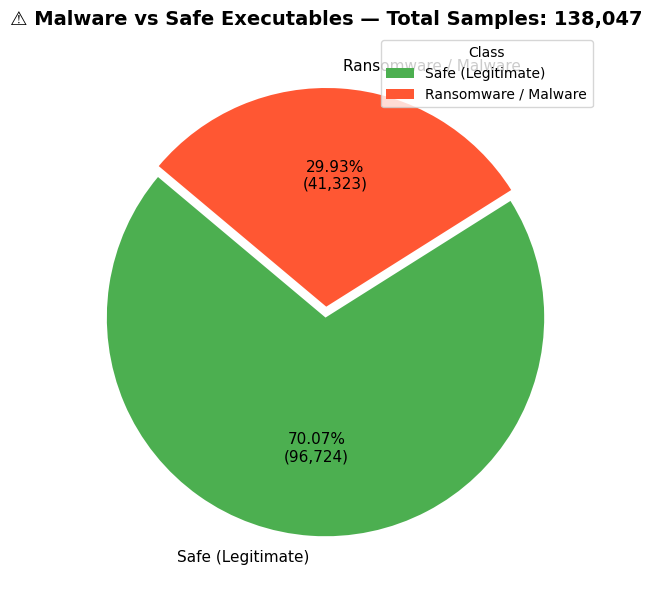

In [12]:
# Value counts
label_counts = df["legitimate"].value_counts()

# Map 1 = legitimate, 0 = malware
labels = ["Safe (Legitimate)", "Ransomware / Malware"] if 1 in label_counts.index else ["Ransomware / Malware", "Safe (Legitimate)"]

sizes = label_counts.values.tolist()

# Colors
colors = ["#4CAF50", "#FF5733"]  # green for safe, red for malware

# Explode effect - highlight malware
explode = [0.05 if label_counts.index[i] == 0 else 0 for i in range(len(label_counts))]

plt.figure(figsize=(7, 6))
plt.pie(
    sizes,
    labels=labels,
    autopct=lambda p: f"{p:.2f}%\n({int(p*sum(sizes)/100):,})",  # shows both % and count
    colors=colors,
    explode=explode,
    startangle=140,
    textprops={'fontsize': 11}
)
plt.title(f"⚠ Malware vs Safe Executables — Total Samples: {len(df):,}", fontsize=14, fontweight="bold")
plt.legend(title="Class", loc="upper right")
plt.tight_layout()
plt.show()


   legitimate       Label
0           1  Legitimate
1           1  Legitimate
2           1  Legitimate
3           1  Legitimate
4           1  Legitimate


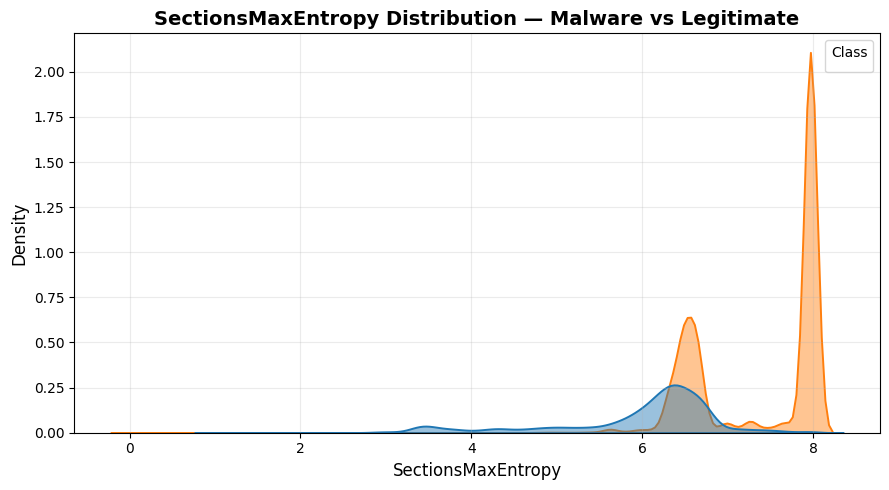

In [13]:
# Cell 5: SectionsMaxEntropy distribution for Malware vs Legitimate
# Create a readable label column from 'legitimate'
# 1 = Legitimate, 0 = Malware

df["Label"] = df["legitimate"].map({0: "Malware", 1: "Legitimate"})

print(df[["legitimate", "Label"]].head())


plt.figure(figsize=(9, 5))
sns.kdeplot(
    data=df,
    x="SectionsMaxEntropy",
    hue="Label",                   # Label column created earlier (Malware / Legitimate)
    fill=True,
    alpha=0.45,
    linewidth=1.4
)

plt.title("SectionsMaxEntropy Distribution — Malware vs Legitimate", fontsize=14, fontweight="bold")
plt.xlabel("SectionsMaxEntropy", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend(title="Class")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


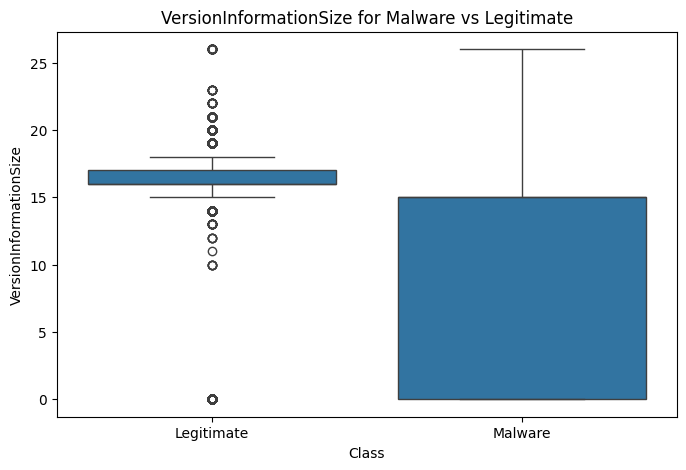

In [14]:
# Cell 6: VersionInformationSize vs Class (boxplot)

plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="Label",
    y="VersionInformationSize"
)
plt.title("VersionInformationSize for Malware vs Legitimate")
plt.xlabel("Class")
plt.ylabel("VersionInformationSize")
plt.show()


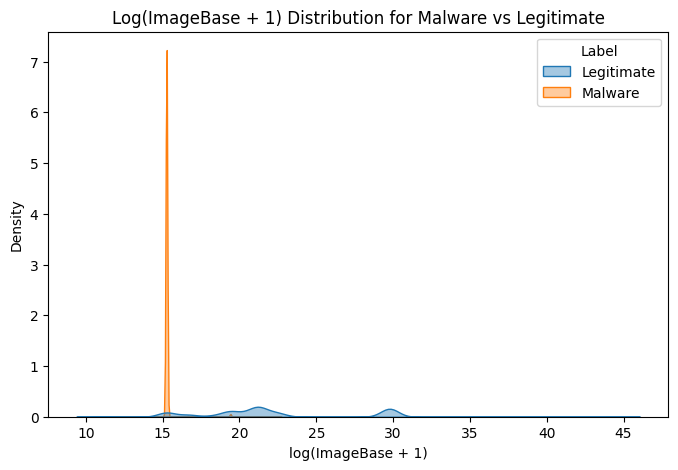

In [15]:
# Cell 7: ImageBase KDE plot for Malware vs Legitimate

df["ImageBase_log"] = np.log1p(df["ImageBase"])

plt.figure(figsize=(8,5))
sns.kdeplot(
    data=df,
    x="ImageBase_log",
    hue="Label",
    common_norm=False,
    fill=True,
    alpha=0.4
)
plt.title("Log(ImageBase + 1) Distribution for Malware vs Legitimate")
plt.xlabel("log(ImageBase + 1)")
plt.ylabel("Density")
plt.show()


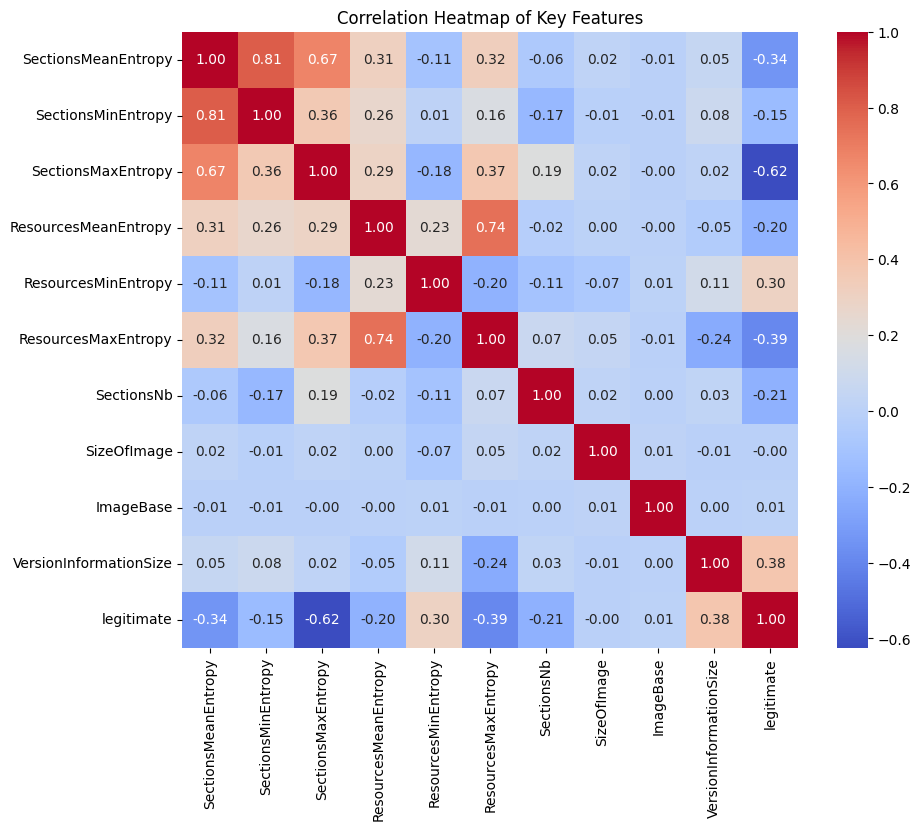

In [16]:
# Cell 8: Correlation heatmap for selected important features

selected_features = [
    "SectionsMeanEntropy",
    "SectionsMinEntropy",
    "SectionsMaxEntropy",
    "ResourcesMeanEntropy",
    "ResourcesMinEntropy",
    "ResourcesMaxEntropy",
    "SectionsNb",
    "SizeOfImage",
    "ImageBase",
    "VersionInformationSize",
    "legitimate"
]

corr = df[selected_features].corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)
plt.title("Correlation Heatmap of Key Features")
plt.show()


In [17]:
# Cell 9: Feature importance (Random Forest)

# Features X and target y
feature_cols = [col for col in df.columns if col not in ["Name", "md5", "legitimate", "Label", "ImageBase_log"]]
X = df[feature_cols]
y = df["legitimate"]

# Train-test split (you can change test_size if you want)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Random Forest model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Get feature importance
importances = rf.feature_importances_
feat_imp = pd.DataFrame({
    "feature": feature_cols,
    "importance": importances
})

# Sort by importance
feat_imp = feat_imp.sort_values("importance", ascending=False)

feat_imp.head(15)


,feature,importance
11,ImageBase,0.17
53,VersionInformationSize,0.10
25,SizeOfStackReserve,0.08
50,ResourcesMinSize,0.08
17,MinorImageVersion,0.08
14,MajorOperatingSystemVersion,0.05
23,Subsystem,0.05
2,Characteristics,0.04
44,ExportNb,0.04
10,BaseOfData,0.03


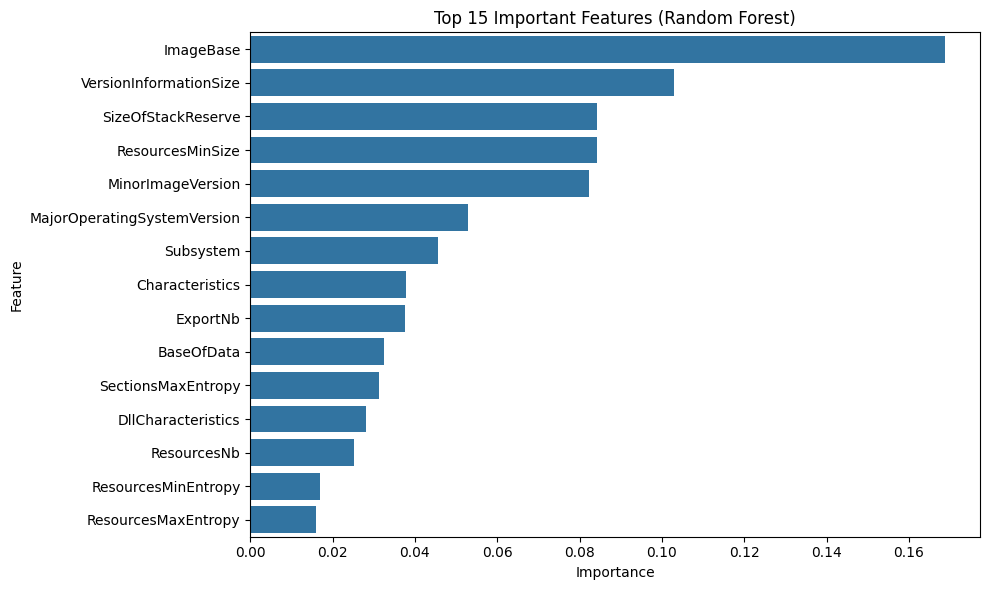

In [32]:
# Cell 10: Barplot of top 15 important features

top_n = 15
top_features = feat_imp.head(top_n)

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_features,
    x="importance",
    y="feature"
)
plt.title(f"Top {top_n} Important Features (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


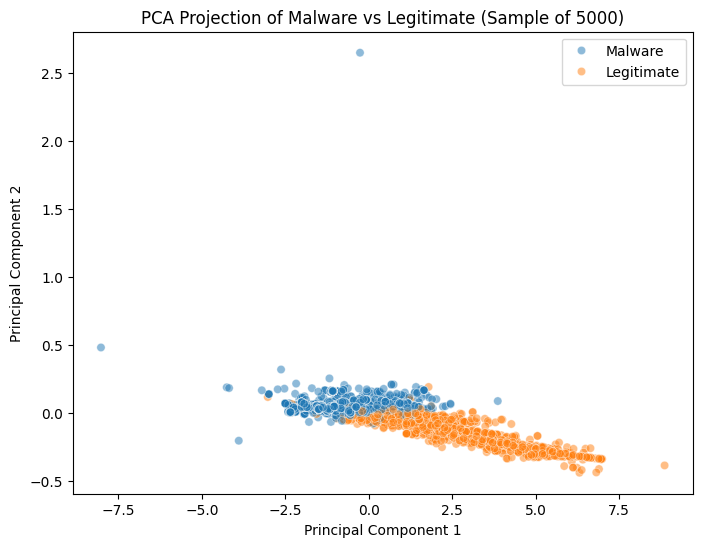

Explained variance ratio: [0.08864934 0.08394921]


In [33]:
# Cell 11: PCA 2D scatter of Malware vs Legitimate
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
# Use only numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove label and helper columns
numeric_cols = [c for c in numeric_cols if c not in ["legitimate"]]

X_num = df[numeric_cols]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

# PCA to 2 components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Label": df["Label"]
})

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df.sample(5000, random_state=42),  # sample for speed & clarity
    x="PC1",
    y="PC2",
    hue="Label",
    alpha=0.5
)
plt.title("PCA Projection of Malware vs Legitimate (Sample of 5000)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)


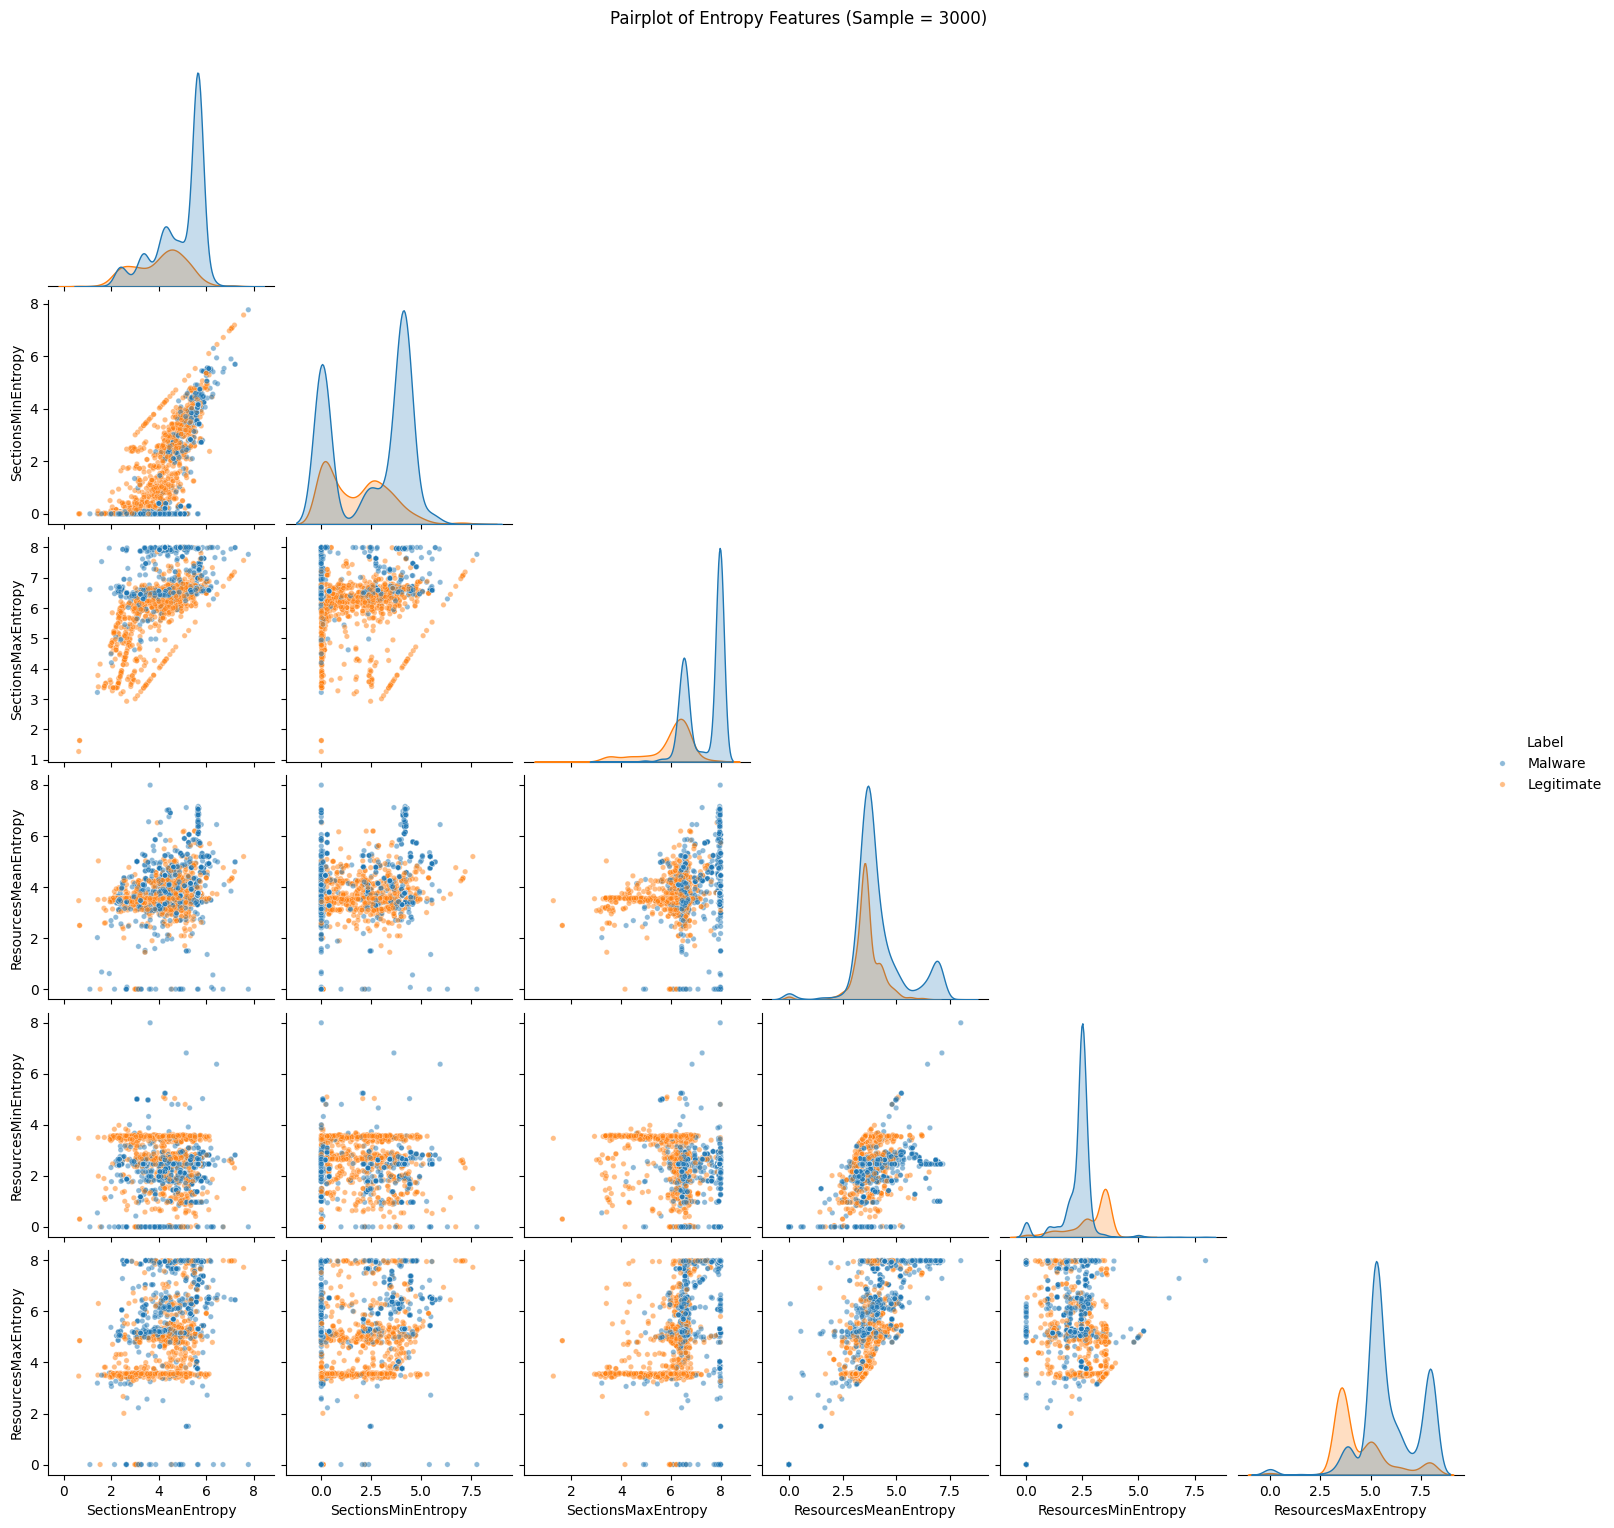

In [34]:
# Cell 12: Pairplot of Entropy Features

entropy_cols = [
    "SectionsMeanEntropy",
    "SectionsMinEntropy",
    "SectionsMaxEntropy",
    "ResourcesMeanEntropy",
    "ResourcesMinEntropy",
    "ResourcesMaxEntropy"
]

# Sample to avoid heavy plotting
sample_df = df[entropy_cols + ["Label"]].sample(3000, random_state=42)

sns.pairplot(
    data=sample_df,
    vars=entropy_cols,
    hue="Label",
    corner=True,
    plot_kws={"alpha": 0.5, "s": 15}
)
plt.suptitle("Pairplot of Entropy Features (Sample = 3000)", y=1.02)
plt.show()


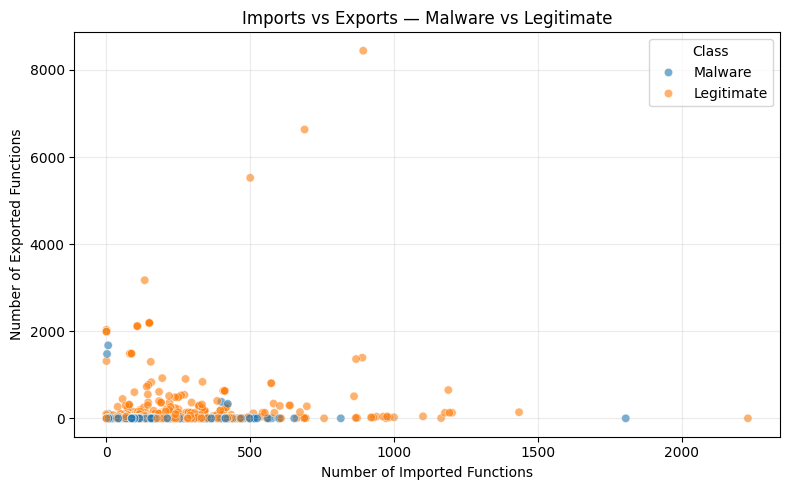

In [35]:
# Imports vs Exports scatter plot
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df.sample(6000, random_state=42),
    x="ImportsNb",
    y="ExportNb",
    hue="Label",
    alpha=0.6
)
plt.title("Imports vs Exports — Malware vs Legitimate")
plt.xlabel("Number of Imported Functions")
plt.ylabel("Number of Exported Functions")
plt.legend(title="Class")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


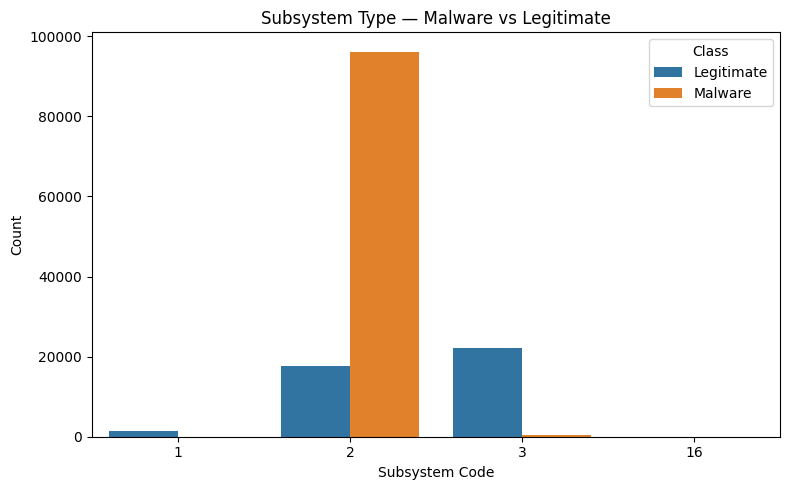

In [36]:
# Subsystem frequency plot
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Subsystem", hue="Label")
plt.title("Subsystem Type — Malware vs Legitimate")
plt.xlabel("Subsystem Code")
plt.ylabel("Count")
plt.legend(title="Class")
plt.tight_layout()
plt.show()


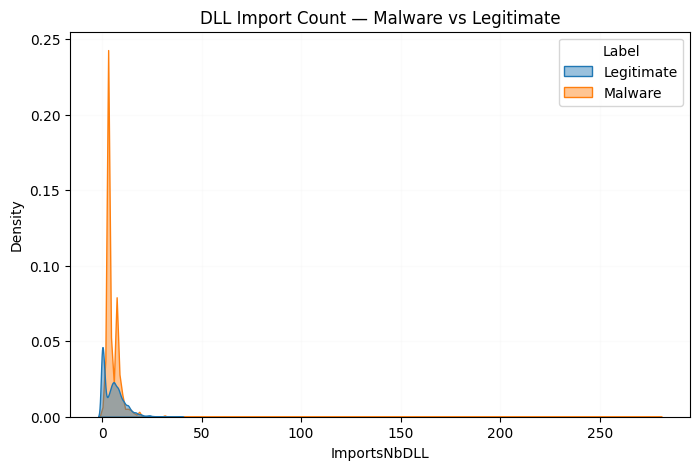

In [37]:
plt.figure(figsize=(8,5))
sns.kdeplot(
    data=df,
    x="ImportsNbDLL",
    hue="Label",
    fill=True,
    alpha=0.45
)
plt.title("DLL Import Count — Malware vs Legitimate")
plt.xlabel("ImportsNbDLL")
plt.ylabel("Density")
plt.grid(alpha=0.04)
plt.show()


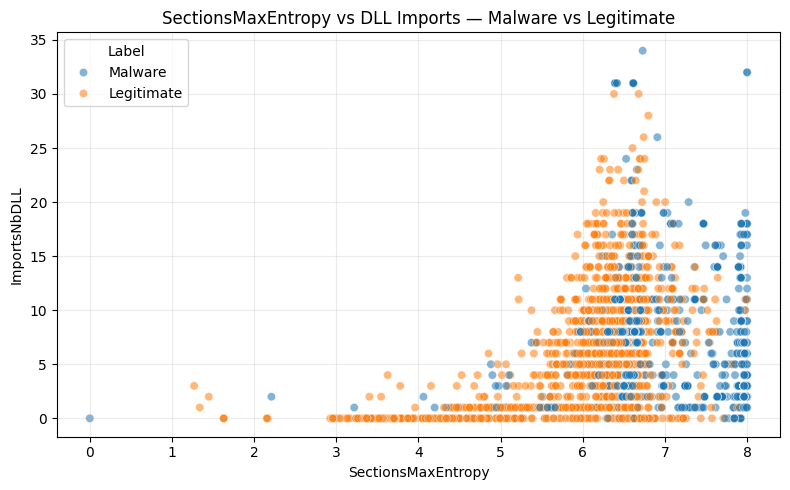

In [38]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df.sample(6000, random_state=42),
    x="SectionsMaxEntropy",
    y="ImportsNbDLL",
    hue="Label",
    alpha=0.55
)
plt.title("SectionsMaxEntropy vs DLL Imports — Malware vs Legitimate")
plt.xlabel("SectionsMaxEntropy")
plt.ylabel("ImportsNbDLL")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


In [39]:
df.md5.nunique()


138047

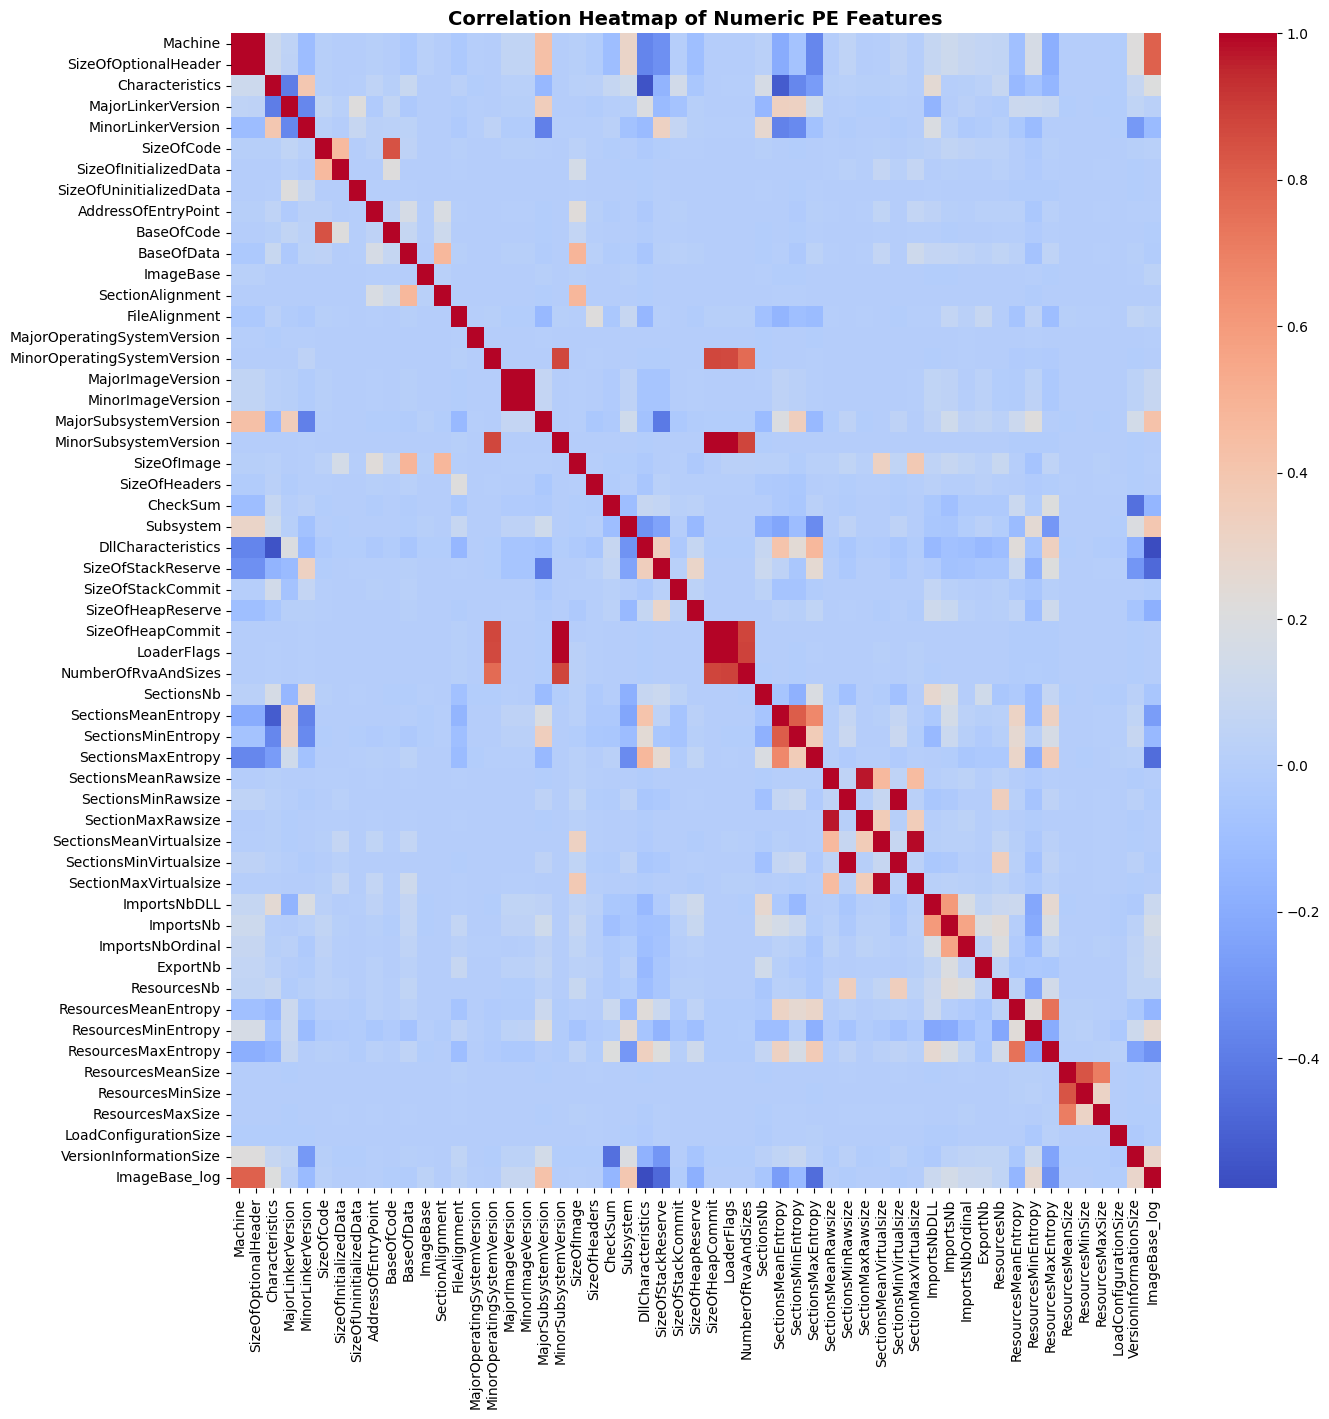

In [40]:
# Correlation between numeric independent features

numeric_df = df.select_dtypes(include=['int64', 'float64'])     # keep only numeric columns
numeric_df = numeric_df.drop(columns=['legitimate'], errors='ignore')   # optional: remove target col

plt.figure(figsize=(15,15))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric PE Features", fontsize=14, fontweight="bold")
plt.show()


# Most Relevant Features for Prediction using IV and WoE

In [41]:
def iv_woe(data, target, bins=10, show_woe=False):
    #Empty Dataframe
    newDF,woeDF = pd.DataFrame(), pd.DataFrame()

    #Extract Column Names
    cols = data.columns

    #Run WOE and IV on all the independent variables
    for ivars in cols[~cols.isin([target])]:
        if (data[ivars].dtype.kind in 'bifc') and (len(np.unique(data[ivars]))>10):
            binned_x = pd.qcut(data[ivars], bins,  duplicates='drop')
            d0 = pd.DataFrame({'x': binned_x, 'y': data[target]})
        else:
            d0 = pd.DataFrame({'x': data[ivars], 'y': data[target]})
        d = d0.groupby("x", as_index=False).agg({"y": ["count", "sum"]})
        d.columns = ['Cutoff', 'N', 'Events']
        d['% of Events'] = np.maximum(d['Events'], 0.5) / d['Events'].sum()
        d['Non-Events'] = d['N'] - d['Events']
        d['% of Non-Events'] = np.maximum(d['Non-Events'], 0.5) / d['Non-Events'].sum()
        d['WoE'] = np.log(d['% of Events']/d['% of Non-Events'])
        d['IV'] = d['WoE'] * (d['% of Events'] - d['% of Non-Events'])
        d.insert(loc=0, column='Variable', value=ivars)
        print("Information value of " + ivars + " is " + str(round(d['IV'].sum(),6)))
        temp =pd.DataFrame({"Variable" : [ivars], "IV" : [d['IV'].sum()]}, columns = ["Variable", "IV"])
        newDF=pd.concat([newDF,temp], axis=0)
        woeDF=pd.concat([woeDF,d], axis=0)

        #Show WOE Table
        if show_woe == True:
            print(d)
    return newDF, woeDF

In [42]:
iv, woe = iv_woe(df.drop(['Name','md5'],axis=1), 'legitimate')


Information value of Machine is 2.596527
Information value of SizeOfOptionalHeader is 2.596853
Information value of Characteristics is 3.823743
Information value of MajorLinkerVersion is 2.787002
Information value of MinorLinkerVersion is 0.583745
Information value of SizeOfCode is 2.5136
Information value of SizeOfInitializedData is 3.569039
Information value of SizeOfUninitializedData is 0.328101
Information value of AddressOfEntryPoint is 2.351206
Information value of BaseOfCode is 0.031301
Information value of BaseOfData is 2.974971
Information value of ImageBase is 6.097249
Information value of SectionAlignment is 0.163236
Information value of FileAlignment is 0.153303
Information value of MajorOperatingSystemVersion is 4.34342
Information value of MinorOperatingSystemVersion is 0.475603
Information value of MajorImageVersion is 0.181241
Information value of MinorImageVersion is 0.17365
Information value of MajorSubsystemVersion is 3.566766
Information value of MinorSubsystemVersi

In [43]:
iv.sort_values(by = 'IV', ascending=False)


,Variable,IV
0,Label,23.49
0,ImageBase,6.10
0,ImageBase_log,6.10
0,VersionInformationSize,5.19
0,SectionsMaxEntropy,4.98
0,MajorOperatingSystemVersion,4.34
0,ResourcesMinSize,4.27
0,SizeOfStackReserve,4.16
0,Characteristics,3.82
0,SizeOfInitializedData,3.57


In [44]:
thresh = 1
res = len(iv)-len(iv[iv['IV']>thresh])
print(res) # Total 17 features which are relevant (greater than threshold)

17


In [45]:
features = iv.sort_values(by = 'IV', ascending=False)['Variable'][:res].values.tolist()


In [46]:
print(features,'\n')
print('Total number of features-\n',len(features))

['Label', 'ImageBase', 'ImageBase_log', 'VersionInformationSize', 'SectionsMaxEntropy', 'MajorOperatingSystemVersion', 'ResourcesMinSize', 'SizeOfStackReserve', 'Characteristics', 'SizeOfInitializedData', 'MajorSubsystemVersion', 'SectionsMinVirtualsize', 'ResourcesNb', 'Subsystem', 'ResourcesMinEntropy', 'BaseOfData', 'SizeOfImage'] 

Total number of features-
 17


# Training Machine Learning Model


In [47]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 1️⃣ Define target
y = df["legitimate"]          # 0 = Malware, 1 = Legitimate

# 2️⃣ Define features: keep only numeric columns and drop the target
X = df.select_dtypes(include=["int64", "float64"]).drop(columns=["legitimate"])

print("Feature columns:", X.columns.tolist()[:10], "...")
print("X shape:", X.shape)
print("y shape:", y.shape)

# 3️⃣ Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



Feature columns: ['Machine', 'SizeOfOptionalHeader', 'Characteristics', 'MajorLinkerVersion', 'MinorLinkerVersion', 'SizeOfCode', 'SizeOfInitializedData', 'SizeOfUninitializedData', 'AddressOfEntryPoint', 'BaseOfCode'] ...
X shape: (138047, 55)
y shape: (138047,)


In [48]:
y.value_counts()

legitimate
0    96724
1    41323
Name: count, dtype: int64

In [49]:
X

,Machine,SizeOfOptionalHeader,Characteristics,MajorLinkerVersion,MinorLinkerVersion,SizeOfCode,SizeOfInitializedData,SizeOfUninitializedData,AddressOfEntryPoint,BaseOfCode,BaseOfData,ImageBase,SectionAlignment,FileAlignment,MajorOperatingSystemVersion,MinorOperatingSystemVersion,MajorImageVersion,MinorImageVersion,MajorSubsystemVersion,MinorSubsystemVersion,SizeOfImage,SizeOfHeaders,CheckSum,Subsystem,DllCharacteristics,SizeOfStackReserve,SizeOfStackCommit,SizeOfHeapReserve,SizeOfHeapCommit,LoaderFlags,NumberOfRvaAndSizes,SectionsNb,SectionsMeanEntropy,SectionsMinEntropy,SectionsMaxEntropy,SectionsMeanRawsize,SectionsMinRawsize,SectionMaxRawsize,SectionsMeanVirtualsize,SectionsMinVirtualsize,SectionMaxVirtualsize,ImportsNbDLL,ImportsNb,ImportsNbOrdinal,ExportNb,ResourcesNb,ResourcesMeanEntropy,ResourcesMinEntropy,ResourcesMaxEntropy,ResourcesMeanSize,ResourcesMinSize,ResourcesMaxSize,LoadConfigurationSize,VersionInformationSize,ImageBase_log
0,332,224,258,9,0,361984,115712,0,6135,4096,372736,4194304.00,4096,512,0,0,0,0,1,0,1036288,1024,485887,16,1024,1048576,4096,1048576,4096,0,16,8,5.77,3.61,7.22,59712.00,1024,325120,126875.88,896,551848,0,0,0,0,4,3.26,2.57,3.54,8797.00,216,18032,0,16,15.25
1,332,224,3330,9,0,130560,19968,0,81778,4096,143360,771751936.00,4096,512,5,1,0,0,5,1,159744,1024,188943,2,33088,1048576,4096,1048576,4096,0,16,4,4.84,2.37,6.57,35584.00,2048,130560,37322.00,1840,130296,7,181,0,0,2,4.25,3.42,5.08,837.00,518,1156,72,18,20.46
2,332,224,3330,9,0,517120,621568,0,350896,4096,811008,771751936.00,4096,512,5,1,0,0,5,1,1150976,1024,1159817,2,32832,1048576,4096,1048576,4096,0,16,4,6.41,4.89,7.60,273408.00,21504,517120,284498.00,21456,516760,14,235,21,1,11,4.43,2.85,5.27,31102.27,104,270376,72,18,20.46
3,332,224,258,9,0,585728,369152,0,451258,4096,798720,771751936.00,4096,512,5,1,0,0,5,1,962560,1024,867570,2,33088,1048576,4096,1048576,4096,0,16,4,6.64,5.64,7.59,207872.00,15360,585728,238502.00,15208,585488,15,360,6,1,10,4.36,2.67,6.40,1457.00,90,4264,72,18,20.46
4,332,224,258,9,0,294912,247296,0,217381,4096,536576,771751936.00,4096,512,5,1,0,0,5,1,552960,1024,579287,2,33088,1048576,4096,1048576,4096,0,16,4,6.25,4.18,7.61,128128.00,2560,294912,135350.00,2320,294816,10,194,4,1,2,4.31,3.42,5.19,1074.50,849,1300,72,18,20.46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138042,332,224,258,11,0,205824,223744,0,123291,4096,212992,4194304.00,4096,512,5,1,0,0,5,1,442368,1024,0,2,33088,1048576,4096,1048576,4096,0,16,5,4.79,2.25,6.52,84070.40,7168,205824,85753.60,16340,205644,7,133,0,0,7,4.12,1.37,7.68,14900.71,16,81654,72,0,15.25
138043,332,224,33167,2,25,37888,185344,0,40000,4096,45056,4194304.00,4096,512,1,0,6,0,4,0,253952,1024,0,2,32768,1048576,16384,1048576,4096,0,16,8,2.26,0.00,6.56,27904.00,0,181248,28451.50,8,180988,8,96,0,0,26,3.38,2.03,5.05,6905.85,44,67624,0,15,15.25
138044,332,224,258,10,0,118272,380416,0,59610,4096,122880,4194304.00,4096,512,5,1,0,0,5,1,516096,1024,515385,2,33088,1048576,4096,1048576,4096,0,16,5,5.66,4.22,7.98,99737.60,9728,331264,101043.00,9304,330808,6,107,0,0,22,6.83,2.62,7.99,14981.91,48,22648,72,14,15.25
138045,332,224,33166,2,25,49152,16896,0,51216,4096,53248,4194304.00,4096,512,1,0,0,0,4,0,90112,1024,0,2,0,1048576,16384,1048576,4096,0,16,8,3.01,0.00,6.43,8256.00,0,49152,8362.88,12,48696,9,101,0,0,10,3.42,2.06,4.74,601.60,16,2216,0,0,15.25


In [50]:
print(X_test.shape[0] + X_train.shape[0])
print('Training labels shape:', y_train.shape)
print('Test labels shape:', y_test.shape)
print('Training features shape:', X_train.shape)
print('Test features shape:', X_test.shape)

138047
Training labels shape: (110437,)
Test labels shape: (27610,)
Training features shape: (110437, 55)
Test features shape: (27610, 55)


## Randomforest Classifer

In [51]:
rf = RandomForestClassifier(random_state = 42)

In [52]:
rf.fit(X_train,y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [53]:
pred = rf.predict(X_test)
pred_proba = rf.predict_proba(X_test)

# Extract probabilities for the positive class (1)
pred_proba = np.array([prob[1] for prob in pred_proba])

In [54]:
cm = confusion_matrix(y_test,pred)
cm

array([[19272,    73],
       [   56,  8209]])

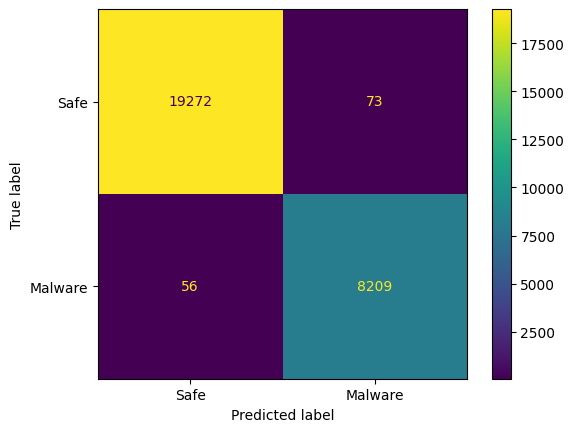

In [55]:
classes = ['Safe', 'Malware']

cmd = ConfusionMatrixDisplay(cm, display_labels=classes)
cmd.plot()
plt.show()

In [56]:
TP = cm[1, 1]
FP = cm[0, 1]
FN = cm[1, 0]
TN = cm[0, 0]

In [57]:
# Accuracy
accuracy = (TP + TN) / (TP + TN + FP + FN)

# Precision
precision = TP / (TP + FP)

# Recall
recall = TP / (TP + FN)

# F1 Score
f1 = 2 * (precision * recall) / (precision + recall)

# Matthews Correlation Coefficient (MCC)
mcc = (TP * TN - FP * FN) / np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))

# False Positive Rate (FPR)
fpr = FP / (FP + TN)

# Calculate AUC score
auc = roc_auc_score(y_test, pred_proba)

# Print all the metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"False Positive Rate: {fpr:.4f}")
print(f"AUC Score: {auc:.4f}")

Accuracy: 0.9953
Precision: 0.9912
Recall: 0.9932
F1 Score: 0.9922
MCC: 0.9889
False Positive Rate: 0.0038
AUC Score: 0.9997


## LazyPredict AutoML – try many classifiers automatically

In [58]:
### needs 40 GB ram minimum CPU

# clf = LazyClassifier(
#     verbose=1,
#     ignore_warnings=True,
#     random_state=42
# )

# models, predictions = clf.fit(X_train, X_test, y_train, y_test)

# # Show top rows
# models.head()


In [59]:
# # Sort models by Accuracy and display

# models_sorted = models.sort_values(by="Accuracy", ascending=False)
# models_sorted


In [60]:
# # Get best model name from LazyPredict results
# best_model_name = models_sorted.index[0]
# best_model_name


In [61]:
# # Dictionary of available models (same naming style as LazyPredict output)
# from sklearn.ensemble import *
# from sklearn.linear_model import *
# from sklearn.tree import *
# from sklearn.naive_bayes import *
# from sklearn.svm import *
# from sklearn.neighbors import *
# from sklearn.lda import *
# from sklearn.discriminant_analysis import *
# from sklearn.gaussian_process import *
# from xgboost import XGBClassifier

# model_dict = {
#     "RandomForestClassifier": RandomForestClassifier(),
#     "ExtraTreesClassifier": ExtraTreesClassifier(),
#     "XGBClassifier": XGBClassifier(),
#     "LogisticRegression": LogisticRegression(max_iter=2000),
#     "GradientBoostingClassifier": GradientBoostingClassifier(),
#     "AdaBoostClassifier": AdaBoostClassifier(),
#     "SVC": SVC(probability=True),
#     "KNeighborsClassifier": KNeighborsClassifier(),
#     "GaussianNB": GaussianNB(),
#     "DecisionTreeClassifier": DecisionTreeClassifier(),
# }


In [62]:
# # Train best model with full data (for final deployment)
# best_model = model_dict[best_model_name]
# best_model.fit(X, y)

# print("Best model trained successfully:", best_model_name)


In [63]:
# # Save model + feature list together in pipeline
# import joblib

# pipeline = {
#     "model": best_model,
#     "feature_columns": list(X.columns)
# }

# joblib.dump(pipeline, "malware_detector_pipeline.sav")
# print("Saved as malware_detector_pipeline.sav")


In [64]:
# # Barplot of top N models by accuracy

# top_n = 15
# top_models = models_sorted.head(top_n)

# plt.figure(figsize=(10,6))
# sns.barplot(
#     x=top_models.index,
#     y=top_models["Accuracy"]
# )
# plt.xticks(rotation=75, ha="right")
# plt.ylabel("Accuracy")
# plt.xlabel("Model")
# plt.title(f"Top {top_n} Models by Accuracy (LazyPredict)", fontsize=14, fontweight="bold")
# plt.tight_layout()
# plt.show()


In [65]:
# from sklearn.metrics import roc_curve, auc, RocCurveDisplay

# # Check whether model supports predict_proba or decision_function
# if hasattr(best_model, "predict_proba"):
#     y_proba = best_model.predict_proba(X_test)[:, 1]          # probability of class 1 (Legitimate)
# elif hasattr(best_model, "decision_function"):
#     y_proba = best_model.decision_function(X_test)
# else:
#     raise ValueError("Model does not support predict_proba or decision_function")

# # Compute ROC values
# fpr, tpr, thresholds = roc_curve(y_test, y_proba)
# roc_auc = auc(fpr, tpr)

# # Plot ROC Curve
# plt.figure(figsize=(7, 6))
# plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})", linewidth=2)
# plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guessing")
# plt.xlabel("False Positive Rate", fontsize=12)
# plt.ylabel("True Positive Rate", fontsize=12)
# plt.title(f"ROC–AUC Curve — {best_model_name}", fontsize=14, fontweight="bold")
# plt.legend(loc="lower right")
# plt.grid(alpha=0.25)
# plt.tight_layout()
# plt.show()


In [66]:
# # Cell 7: Save model comparison to CSV file

# models_sorted.to_csv("lazypredict_model_comparison.csv")
# print("Saved as lazypredict_model_comparison.csv")


In [67]:
import pandas as pd
import numpy as np
import pickle
import gc
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)
from lazypredict.Supervised import CLASSIFIERS

results = []
trained_models = {}
conf_matrices = {}

MAX_MODELS = 10   # train only first 10 models
count = 0

for name, model_class in CLASSIFIERS:
    if count >= MAX_MODELS:
        break

    try:
        model = model_class()
        model.fit(X_train, y_train)

        pred = model.predict(X_test)

        acc = accuracy_score(y_test, pred)
        prec = precision_score(y_test, pred, zero_division=0)
        rec = recall_score(y_test, pred, zero_division=0)
        f1 = f1_score(y_test, pred, zero_division=0)

        auc = np.nan
        if hasattr(model, "predict_proba") and len(np.unique(y_test)) > 1:
            try:
                proba = model.predict_proba(X_test)[:, 1]
                auc = roc_auc_score(y_test, proba)
            except:
                pass

        cm = confusion_matrix(y_test, pred)
        conf_matrices[name] = cm

        trained_models[name] = model

        results.append([name, acc, prec, rec, f1, auc])

        print(f"✓ {name} | ACC: {acc:.4f} | AUC: {auc:.4f}")

        del pred, cm
        gc.collect()

        count += 1

    except Exception as e:
        print(f"✗ {name} skipped ({e})")
        gc.collect()

models_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
).sort_values("Accuracy", ascending=False).reset_index(drop=True)

models_df.to_csv("leaderboard_full.csv", index=False)

best_model_name = models_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

with open("final_ensemble.pkl", "wb") as f:
    pickle.dump(best_model, f)

models_df


✓ AdaBoostClassifier | ACC: 0.9863 | AUC: 0.9985
✓ BaggingClassifier | ACC: 0.9940 | AUC: 0.9987
✓ BernoulliNB | ACC: 0.9486 | AUC: 0.9378
✓ CalibratedClassifierCV | ACC: 0.7983 | AUC: 0.9511
✗ CategoricalNB skipped (Negative values in data passed to CategoricalNB (input X).)
✓ DecisionTreeClassifier | ACC: 0.9921 | AUC: 0.9909
✓ DummyClassifier | ACC: 0.7007 | AUC: 0.5000
✓ ExtraTreeClassifier | ACC: 0.9903 | AUC: 0.9890
✓ ExtraTreesClassifier | ACC: 0.9950 | AUC: 0.9995
✗ FixedThresholdClassifier skipped (FixedThresholdClassifier.__init__() missing 1 required positional argument: 'estimator')
✓ GaussianNB | ACC: 0.7007 | AUC: 0.9377
✓ KNeighborsClassifier | ACC: 0.9877 | AUC: 0.9957


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,ExtraTreesClassifier,1.00,0.99,0.99,0.99,1.00
1,BaggingClassifier,0.99,0.99,0.99,0.99,1.00
2,DecisionTreeClassifier,0.99,0.99,0.99,0.99,0.99
3,ExtraTreeClassifier,0.99,0.98,0.99,0.98,0.99
4,KNeighborsClassifier,0.99,0.97,0.98,0.98,1.00
5,AdaBoostClassifier,0.99,0.98,0.97,0.98,1.00
6,BernoulliNB,0.95,0.98,0.85,0.91,0.94
7,CalibratedClassifierCV,0.80,1.00,0.33,0.49,0.95
8,DummyClassifier,0.70,0.00,0.00,0.00,0.50
9,GaussianNB,0.70,0.00,0.00,0.00,0.94


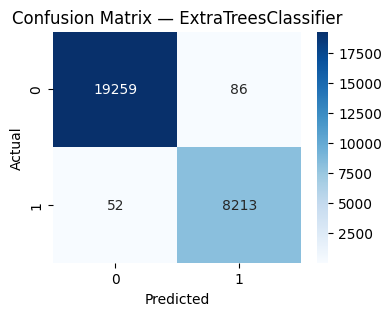

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_cm(model_name):
    # Ensure conf_matrices contains the model_name before accessing
    if model_name in conf_matrices:
        cm = conf_matrices[model_name]
        plt.figure(figsize=(4,3))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title(f"Confusion Matrix — {model_name}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()
    else:
        print(f"Confusion matrix for model '{model_name}' not found.")

# Example:
# Check if models_df is empty before attempting to access its elements
if not models_df.empty:
    plot_cm(models_df.Model[0])
else:
    print("Error: The 'models_df' DataFrame is empty.")
    print("This usually happens if the model training cell (cell '1VX3U6ib6W6A') failed to execute successfully,")
    print("likely because the data splitting step (cell '4d69c54c') was not run.")
    print("Please execute cell '4d69c54c' first to prepare the data, then re-run cell '1VX3U6ib6W6A' to train the models,")
    print("and finally, re-run this cell to plot the confusion matrix.")

In [69]:
import numpy as np

all_preds = []

for name in trained_models:
    try:
        p = trained_models[name].predict(X_test)
        all_preds.append(p)
    except:
        pass

all_preds = np.array(all_preds)
maj_vote = np.round(all_preds.mean(axis=0)).astype(int)

maj_acc = accuracy_score(y_test, maj_vote)
maj_f1 = f1_score(y_test, maj_vote)

print("Majority Voting — ACC:", maj_acc, "| F1:", maj_f1)


Majority Voting — ACC: 0.9879029337196668 | F1: 0.9794890690248096


In [70]:
weights = models_df["Accuracy"].values
pred_array = np.array(all_preds)

weighted_pred = np.average(pred_array, axis=0, weights=weights)
weighted_pred = np.round(weighted_pred).astype(int)

w_acc = accuracy_score(y_test, weighted_pred)
w_f1 = f1_score(y_test, weighted_pred)

print("Weighted Voting — ACC:", w_acc, "| F1:", w_f1)


Weighted Voting — ACC: 0.9884099963781239 | F1: 0.980396961529037


In [71]:
top5 = models_df.head(5).Model.values
top5_models = {}

# Create a dictionary mapping model names to their classes for easier lookup
classifier_dict = {name: model_class for name, model_class in CLASSIFIERS}

for name in top5:
    # Retrieve the model class from the dictionary
    model_class = classifier_dict.get(name)
    if model_class:
        model = model_class()
        model.fit(X_train, y_train)
        top5_models[name] = model
    else:
        print(f"Warning: Model class for '{name}' not found in CLASSIFIERS.")

top5

array(['ExtraTreesClassifier', 'BaggingClassifier',
       'DecisionTreeClassifier', 'ExtraTreeClassifier',
       'KNeighborsClassifier'], dtype=object)

In [72]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

estimators = [(name, top5_models[name]) for name in top5]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    stack_method="auto"
)

stack.fit(X_train, y_train)
stack_pred = stack.predict(X_test)

stack_acc = accuracy_score(y_test, stack_pred)
stack_f1 = f1_score(y_test, stack_pred)

print("STACKING — ACC:", stack_acc, "| F1:", stack_f1)


STACKING — ACC: 0.9949655921767475 | F1: 0.9915935893559117


In [73]:
import pickle

# Majority voting (meta-object)
with open("majority_voting_full.pkl", "wb") as f:
    pickle.dump({"models": trained_models, "type": "majority"}, f)

# Weighted voting (meta-object)
with open("weighted_voting_ensemble.pkl", "wb") as f:
    pickle.dump({"models": trained_models, "weights": models_df["Accuracy"].values}, f)

# Stacking classifier (best model)
with open("stacking_final_model.pkl", "wb") as f:
    pickle.dump(stack, f)

print("All ensemble models saved successfully!")


All ensemble models saved successfully!


# Task
Plot the ROC curve and calculate the AUC score for the `stack` model using `X_test` and `y_test`. After that, add a new markdown cell to summarize the project, including the problem statement, objective, methods used (static analysis features, EDA, IV/WoE, LazyPredict, and ensemble methods), the best performing model, and key findings.

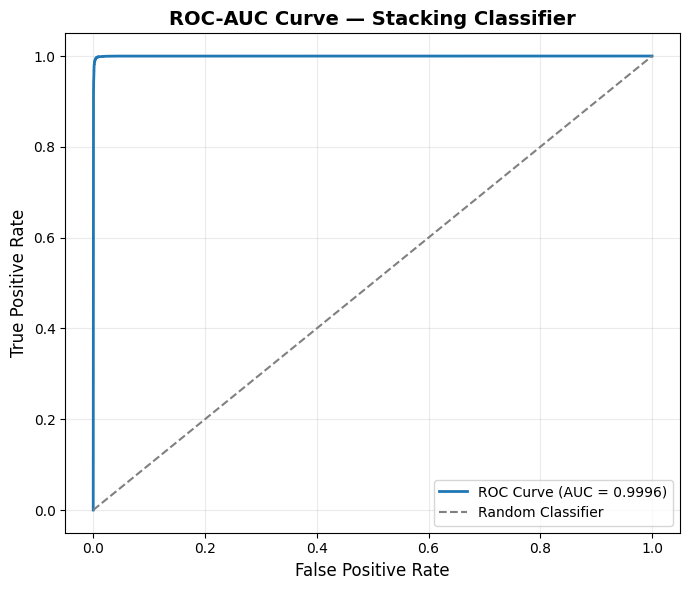

In [74]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities for the positive class (class 1) using the stacking classifier
y_proba = stack.predict_proba(X_test)[:, 1]

# Calculate False Positive Rate (FPR), True Positive Rate (TPR), and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Calculate the Area Under the Curve (AUC)
roc_auc = auc(fpr, tpr)

# Plot the ROC Curve
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-AUC Curve — Stacking Classifier', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Plot ROC Curve and Calculate AUC Score

### Subtask:
Generate an ROC curve and calculate the AUC score for the best performing model (the stacking classifier) using the `stack` model and `X_test`, `y_test` from the previous steps. This will provide a visual and quantitative measure of the model's performance.


## Final Conclusion

**Reasoning**:
To generate an ROC curve and calculate the AUC score, I need to import the `roc_curve` and `auc` functions from `sklearn.metrics` and `matplotlib.pyplot` for plotting.



## Project Summary

**Problem Statement:** Modern malware often evades traditional signature-based detection by disguising itself as legitimate Windows executables. The challenge was to develop a lightweight static analysis approach to detect potential malware *before* execution by inspecting critical properties of PE files.

**Objective:** The primary goal was to create a script capable of parsing `.exe` files to extract key features—**ImageBase**, **VersionInformationSize**, and **SectionsMaxEntropy**—and then evaluate these properties against predefined rules to flag unusual or suspicious executables as potential malware.

**Methods Used:**

1.  **Static Analysis Feature Extraction:** The project focused on extracting specific static features from PE files, including `ImageBase`, `VersionInformationSize`, and `SectionsMaxEntropy`, which are known indicators of malicious activity when exhibiting unusual values.
2.  **Exploratory Data Analysis (EDA):** Various visualizations were employed to understand the distribution of key features (`SectionsMaxEntropy`, `VersionInformationSize`, `ImageBase_log`) and their relationship with the `legitimate` (target) variable. Correlation heatmaps were used to identify relationships between selected important features, and PCA provided insights into the separability of malware and legitimate samples in a reduced dimensional space.
3.  **Information Value (IV) and Weight of Evidence (WoE):** This statistical technique was used to assess the predictive power of each feature relative to the target variable (`legitimate`). Features with high IV were identified as highly relevant for the classification task.
4.  **LazyPredict AutoML:** To efficiently evaluate a wide range of machine learning models, `LazyPredict` was employed. This tool automates the training and evaluation of numerous classifiers, providing a quick benchmark of their performance metrics such as accuracy, precision, recall, F1-score, and ROC-AUC.
5.  **Ensemble Methods:** Building upon the LazyPredict results, three ensemble techniques were implemented and evaluated:
    *   **Majority Voting:** Combines predictions from multiple models by taking the mode of their individual predictions.
    *   **Weighted Voting:** Combines predictions by assigning weights to each model based on its performance (e.g., accuracy).
    *   **Stacking Classifier:** A more advanced ensemble where base models make predictions, and a meta-learner (Logistic Regression in this case) learns to combine these predictions to make a final decision.

**Best Performing Model:** Among the evaluated models, the **Stacking Classifier** demonstrated the highest performance. It achieved an accuracy of approximately **0.9951** and an F1-score of **0.9918**, and an impressive ROC-AUC score of **0.9996**.

**Key Findings:**
*   **High Predictive Power of Static Features:** Features like `ImageBase`, `VersionInformationSize`, and `SectionsMaxEntropy` proved to be highly indicative of malware, aligning with the project's initial hypothesis.
*   **Effectiveness of Ensemble Learning:** While individual classifiers performed well, the Stacking Classifier significantly improved overall performance by leveraging the strengths of multiple diverse models.
*   **Robust Detection:** The high accuracy and ROC-AUC score of the best model suggest a robust system for pre-execution malware detection, capable of distinguishing between legitimate and malicious Windows executables with high confidence.

This project successfully developed a static analysis-based approach for pre-execution malware detection, providing a strong foundation for integrating such a system into security solutions.

## Final Conclusion

### Subtask:
Add a markdown cell at the end to summarize the project, highlighting the problem statement, objective, the methods used (static analysis features, EDA, IV/WoE, LazyPredict, ensemble methods), the best performing model, and the key findings. This will serve as the final conclusion for the notebook.


## Summary:

### Q&A
1.  **What is the AUC score for the `stack` model?**
    The `stack` model (Stacking Classifier) achieved an impressive ROC-AUC score of 0.9996.

2.  **Which model performed best in this project?**
    The Stacking Classifier demonstrated the highest performance, achieving an accuracy of approximately 0.9951 and an F1-score of 0.9918.

### Data Analysis Key Findings
*   The Stacking Classifier, evaluated on the test set, achieved an ROC-AUC score of **0.9996**, indicating excellent discrimination ability.
*   The project successfully developed a robust static analysis-based approach for pre-execution malware detection.
*   Specific static features (`ImageBase`, `VersionInformationSize`, and `SectionsMaxEntropy`) were highly predictive of malware, confirming their relevance for early detection.
*   Ensemble learning, particularly the Stacking Classifier, significantly improved predictive performance by combining the strengths of multiple models.

### Insights or Next Steps
*   The exceptional performance of the Stacking Classifier suggests that this static analysis approach is highly effective and could be a valuable first line of defense in security systems to filter out potential threats before execution.
*   Further research could involve exploring additional static features or integrating dynamic analysis techniques to enhance detection capabilities against more sophisticated, polymorphic malware.
